<a href="https://www.kaggle.com/code/vedikagupta0/predicting-churn-baseline-model-0-76?scriptVersionId=304340162" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [54]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [55]:
id_col = ['id']

In [56]:
df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [57]:
profile = ProfileReport(df, explorative=True)
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [58]:
df.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [59]:
profile

#### 1. No null values are observed.
#### 2. Imbalance is observed in PhoneService, SeniorCitizen and Dependents.
#### 3. TotalCharges is skewed probably.
#### 4. Churn i.e. Target column is facing major imbalance.
#### 5. StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity and InternetService has some weird pattern for NO/ No internet, which can be a useful insight for our modeling.

In [60]:
cat_cols = df.describe(include='object').columns[:-1]

In [61]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    tf[col] = le.transform(tf[col])
    
    encoders[col] = le
    
    # mapping: original -> encoded
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    print(mapping)
    print("-" * 40)

gender mapping:
{'Female': np.int64(0), 'Male': np.int64(1)}
----------------------------------------
Partner mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
Dependents mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
PhoneService mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
MultipleLines mapping:
{'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
InternetService mapping:
{'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
----------------------------------------
OnlineSecurity mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
OnlineBackup mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
DeviceProtection mapping:
{'No': np.int64(0),

In [62]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

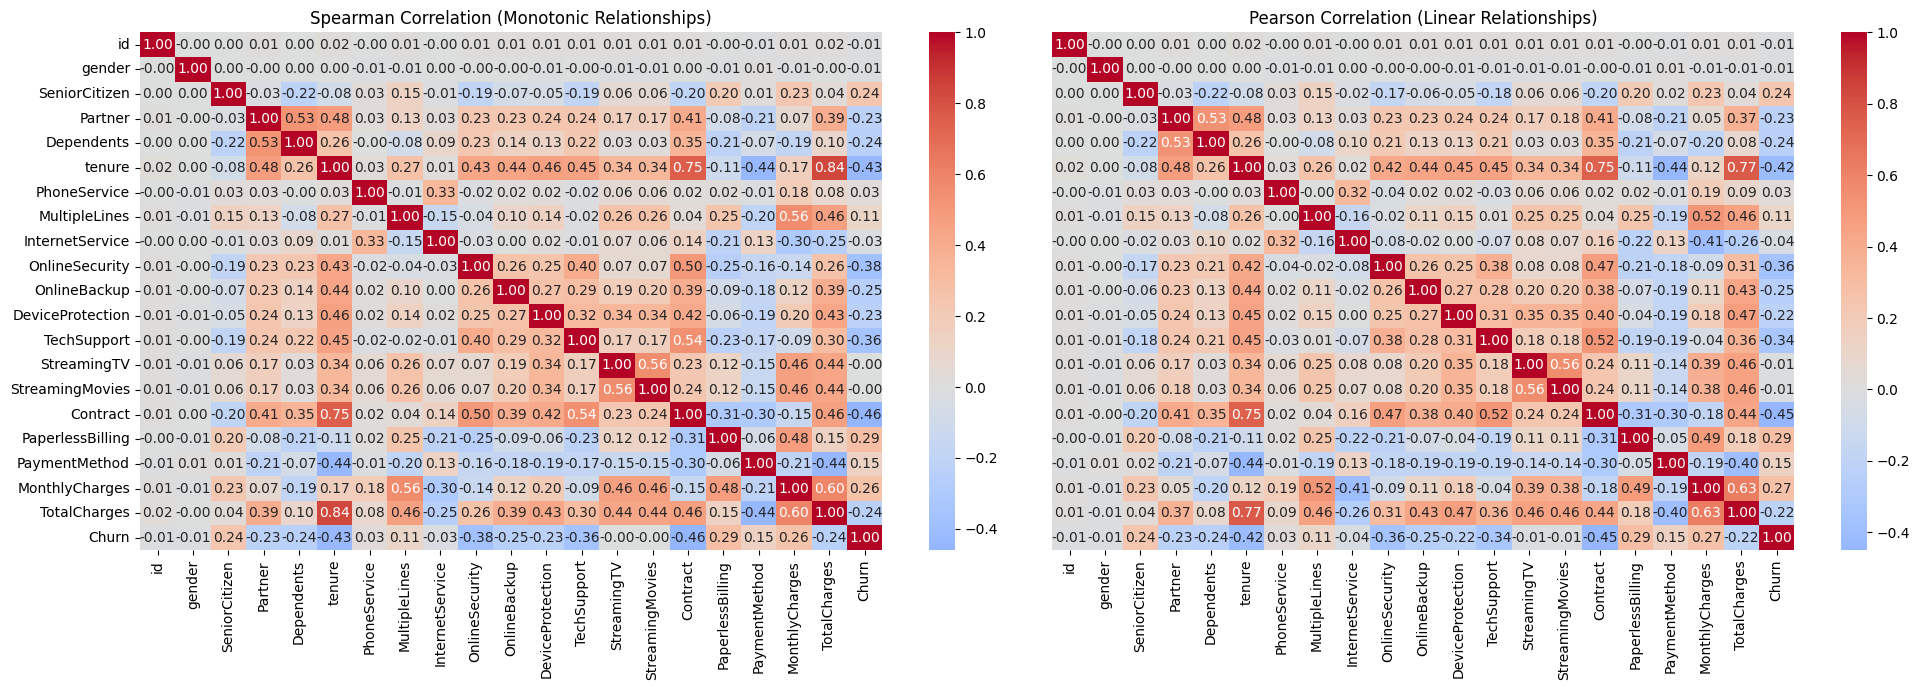

In [63]:
# correlations
spearman_corr = df.corr(method="spearman")
kendall_corr  = df.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships)")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships)")

plt.tight_layout()
plt.show()

In [64]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 1).all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(140727, 21)

In [65]:
100 - ((df.shape[0] - 140727)/ df.shape[0])*100

23.68367906777921

#### Even after being a synthetic dataset, these 6 columns possess same value conveys an important detail.

In [66]:
df['dominance_of_nointernetservice'] = (df[cols] == 1).all(axis=1)

In [67]:
df.dominance_of_nointernetservice.value_counts()

dominance_of_nointernetservice
False    453467
True     140727
Name: count, dtype: int64

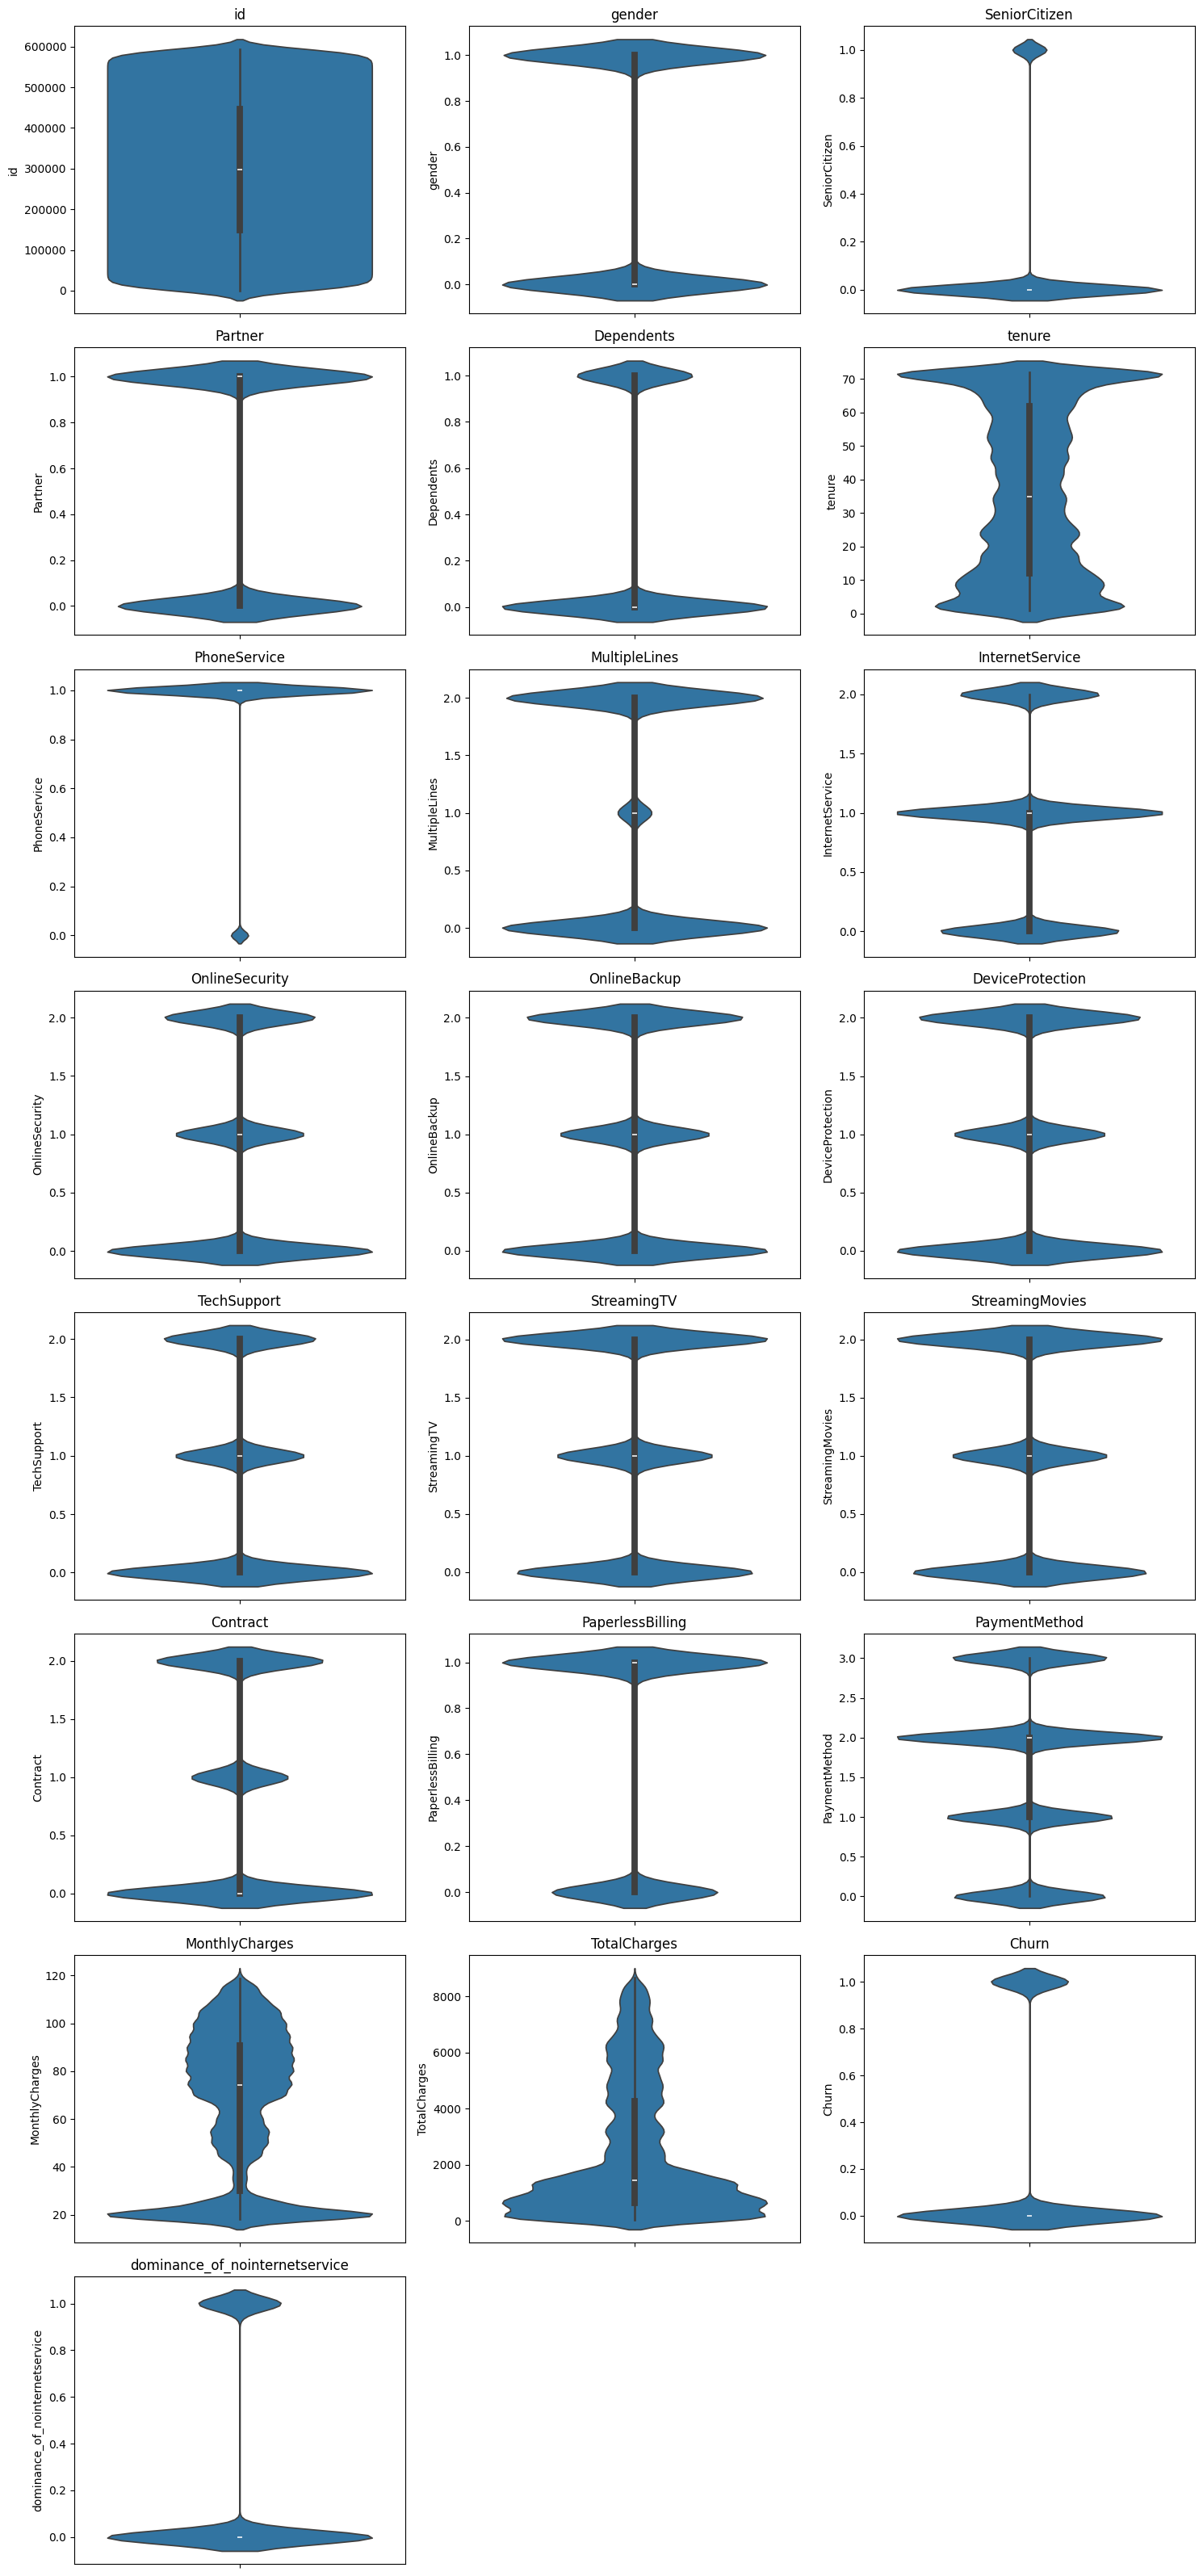

In [68]:
n = len(df.columns)
ncols = 3
nrows = math.ceil(n / ncols)

# violin plots in grid
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.violinplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()